# Project Innowise



In [1]:
%pip install numpy pandas matplotlib seaborn plotly nbformat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from jedi.inference import lazy_value
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Merge data


In [3]:
items = pd.read_csv('olist_order_items_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translations = pd.read_csv('product_category_name_translation.csv')
df_raw = (items.merge(orders, on='order_id', how='left')
           .merge(customers, on='customer_id', how='left')
           .merge(products, on='product_id', how='left')
           .merge(translations, on='product_category_name', how='left'))

df = df_raw.sample(n=10000, random_state=24).copy()
display(df.head(30))

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
83715,be1aff1e5ed8adabab251a979e96bdb9,3,4052517cac9e78357d895976124f6972,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-07-21 14:35:13,150.00,27.59,826c677b00d964c53329e5ea1b5bddab,delivered,2017-07-14 14:20:03,2017-07-14 14:35:13,2017-07-17 21:34:59,2017-07-27 16:44:30,2017-08-18 00:00:00,76d5f0e306da4dcc92bb8c4a00b4f891,63260,brejo santo,CE,eletronicos,31.0,736.0,3.0,800.0,35.0,30.0,40.0,electronics
70483,a0e058d95d9625fbb9a4bd69fd6d0996,1,119cfca51257edda1acecb4b8576ec48,cd68562d3f44870c08922d380acae552,2017-08-09 03:10:54,169.00,12.68,1d46f6ccc4985ed63a309848cad48bd5,delivered,2017-08-01 17:18:33,2017-08-03 03:10:54,2017-08-03 18:51:42,2017-08-09 23:07:40,2017-08-21 00:00:00,2bc00078081fa117b125f5bd5e145764,12606,lorena,SP,cool_stuff,59.0,1618.0,3.0,600.0,16.0,14.0,15.0,cool_stuff
28591,411863c544c533d3918d4e274ce334c8,1,e78506414d2563b6414cfd84b7fa0802,fe2032dab1a61af8794248c8196565c9,2017-12-06 12:30:29,152.00,18.34,a8fbdfdfcd4b5f2f67dcd87ca80add6c,delivered,2017-11-29 09:54:11,2017-11-30 13:31:21,2017-12-05 18:13:15,2018-01-03 21:21:59,2017-12-27 00:00:00,16b4e6a5fcbd35d8b50d07c047f30d17,60541,fortaleza,CE,perfumaria,58.0,827.0,1.0,460.0,20.0,14.0,20.0,perfumery
19801,2d736835b63820cfdc9c9e7eef22daf2,1,9bb8ca338e5588c361e34eae02e8fad6,620c87c171fb2a6dd6e8bb4dec959fc6,2017-11-21 02:55:51,59.90,14.01,c06dfa7240c4304b19b4246f3b107d38,delivered,2017-11-14 10:40:21,2017-11-15 02:56:21,2017-11-16 15:34:49,2017-11-17 20:11:36,2017-12-04 00:00:00,4249a1724d282a6356179a862fe02722,27253,volta redonda,RJ,beleza_saude,37.0,314.0,1.0,431.0,19.0,17.0,15.0,health_beauty
71453,a2f4de10fceff6c008efd19d2b99725f,1,cd7f7f00061ea28ae06afc6dc5786cf0,5a8e7d5003a1f221f9e1d6e411de7c23,2018-08-14 12:04:28,79.90,8.72,b66217448555073a1804c56d701fa4e1,delivered,2018-08-11 11:48:41,2018-08-11 12:04:28,2018-08-13 15:09:00,2018-08-15 17:48:37,2018-08-20 00:00:00,74635e4c481883885fbc9429b880df02,13015,campinas,SP,moveis_decoracao,33.0,1183.0,5.0,350.0,68.0,8.0,13.0,furniture_decor
45577,677c865b89aa97e7dbeb4bfbb50bbcfd,1,e2bab04d6a471ed7a3629fbe2a64b55a,beadbee30901a7f61d031b6b686095ad,2018-08-30 23:24:13,85.00,7.86,529d3f46584a8fa9027777a9c7d5a1fc,delivered,2018-08-14 23:08:33,2018-08-14 23:24:13,2018-08-23 12:51:00,2018-08-24 23:42:42,2018-08-31 00:00:00,e1881c7d99c20ca24a49cf18f115db40,2435,sao paulo,SP,perfumaria,51.0,950.0,1.0,300.0,16.0,19.0,14.0,perfumery
64106,92719473371fb9439b386d53d12470a8,1,dc52f0f5d3ec37a93eaf956cde4e5d2c,6560211a19b47992c3666cc44a7e94c0,2017-10-19 20:46:38,49.00,21.15,5944fcd0423637dc7497ef10187e073b,delivered,2017-10-13 19:25:59,2017-10-13 19:46:38,2017-10-16 20:12:41,2017-11-23 21:13:07,2017-11-06 00:00:00,c601f5196438b2836f6de978734b2829,49027,aracaju,SE,relogios_presentes,60.0,539.0,7.0,400.0,16.0,2.0,20.0,watches_gifts
14021,1fedda1b294263f50d8f0f78bf5c3e6a,1,7c2d0df8e5fbfa71d54a400b33a8502e,7e1fb0a3ebfb01ffb3a7dae98bf3238d,2017-05-10 21:25:17,116.00,16.51,08f68c9d6b891c565a87205b547d21a8,delivered,2017-05-04 21:15:50,2017-05-04 21:25:17,2017-05-05 16:26:50,2017-05-16 10:12:49,2017-05-31 00:00:00,fcbbe2856825553e6ed2bfbb252587fc,29730,baixo guandu,ES,beleza_saude,59.0,1515.0,1.0,138.0,12.0,9.0,18.0,health_beauty
44758,65c28faddc1bdb2d3d5de4f713de3f9a,1,a56fbff66c12c1ef311cac69e7f2d5fb,1025f0e2d44d7041d6cf58b6550e0bfa,2018-04-16 04:10:47,45.00,17.06,e8334d453a2049e7a529d772be66ad61,delivered,2018-04-06 12:54:10,2018-04-10 04:10:47,2018-04-11 20:22:01,2018-04-24 18:29:49,2018-05-04 00:00:00,c68a95b096e94c5c6e1f47c06d847171,41770,salv

Adding finantial data

In [4]:
to_delete = ['product_category_name','product_name_lenght','product_description_lenght','product_photos_qty','customer_zip_code_prefix','product_photos_qty','order_approved_at','order_delivered_carrier_date','shipping_limit_date','order_estimated_delivery_date','product_length_cm','product_width_cm','product_height_cm','seller_id','order_item_id']
df = df.drop(columns=to_delete, errors='ignore')
print(df.columns.tolist())

['order_id', 'product_id', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'customer_unique_id', 'customer_city', 'customer_state', 'product_weight_g', 'product_category_name_english']


In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
np.random.seed(24)
df['cost_multiplier'] = np.random.uniform(0.40, 0.70, size=len(df))
df['product_cost'] = round(df['cost_multiplier'] * df['price'],2)
df['profit_margin'] = df['price'] - df['product_cost']
check = df.groupby('product_category_name_english').size().sort_values(ascending=False)
print(len(check))

68


Mapping departments for categories

In [6]:
department_groups = {
    'Home & Living': ['bed_bath_table', 'furniture_decor', 'housewares', 'garden_tools',
                      'home_construction', 'office_furniture', 'home_confort',
                      'furniture_living_room', 'home_appliances', 'home_appliances_2'],

    'Health & Beauty': ['health_beauty', 'perfumery', 'baby', 'diapers_and_hygiene'],

    'Tech & Electronics': ['computers_accessories', 'telephony', 'electronics', 'audio',
                           'computers', 'fixed_telephony', 'tablets_printing_image'],

    'Fashion & Accessories': ['watches_gifts', 'fashion_bags_accessories', 'fashion_shoes',
                              'fashion_male_clothing', 'fashion_female_clothing',
                              'fashion_underwear_beach', 'luggage_accessories'],

    'Sports & Leisure': ['sports_leisure', 'toys', 'consoles_games', 'musical_instruments'],

    'Auto & Tools': ['auto', 'construction_tools_construction', 'costruction_tools_tools',
                     'industry_commerce_and_business'],

    'Books & Media': ['stationery', 'books_general_interest', 'books_technical',
                      'books_imported', 'cds_dvds_musicals', 'dvds_blu_ray'],

    'Food & Drinks': ['food', 'drinks', 'food_drink']
}

full_maping = {}
for dept, categories in department_groups.items():
    for category in categories:
        full_maping[category] = dept
df['Department'] = df['product_category_name_english'].map(full_maping).fillna('Other')
display(df.groupby('Department').size().sort_values(ascending=False))

Department
Home & Living            2971
Tech & Electronics       1481
Health & Beauty          1464
Sports & Leisure         1264
Other                    1022
Fashion & Accessories     843
Auto & Tools              482
Books & Media             352
Food & Drinks             121
dtype: int64

Loyalty program


In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['Loyalty_Status'] = 'Standard'
scd_date = pd.to_datetime('2018-01-01')
unique_cust = df['customer_unique_id'].dropna().unique()
prem_cust = np.random.choice(unique_cust, size=int(len(unique_cust)*0.2), replace=False)
df.loc[(df['customer_unique_id'].isin(prem_cust)) & (df['order_purchase_timestamp'] >= scd_date), 'Loyalty_Status'] = 'Premium'
display(df.head(15))

,order_id,product_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,customer_unique_id,customer_city,customer_state,product_weight_g,product_category_name_english,cost_multiplier,product_cost,profit_margin,Department,Loyalty_Status
83715,be1aff1e5ed8adabab251a979e96bdb9,4052517cac9e78357d895976124f6972,150.00,27.59,826c677b00d964c53329e5ea1b5bddab,delivered,2017-07-14 14:20:03,2017-07-27 16:44:30,76d5f0e306da4dcc92bb8c4a00b4f891,brejo santo,CE,800.0,electronics,0.688005,103.20,46.80,Tech & Electronics,Standard
70483,a0e058d95d9625fbb9a4bd69fd6d0996,119cfca51257edda1acecb4b8576ec48,169.00,12.68,1d46f6ccc4985ed63a309848cad48bd5,delivered,2017-08-01 17:18:33,2017-08-09 23:07:40,2bc00078081fa117b125f5bd5e145764,lorena,SP,600.0,cool_stuff,0.609854,103.07,65.93,Other,Standard
28591,411863c544c533d3918d4e274ce334c8,e78506414d2563b6414cfd84b7fa0802,152.00,18.34,a8fbdfdfcd4b5f2f67dcd87ca80add6c,delivered,2017-11-29 09:54:11,2018-01-03 21:21:59,16b4e6a5fcbd35d8b50d07c047f30d17,fortaleza,CE,460.0,perfumery,0.699960,106.39,45.61,Health & Beauty,Standard
19801,2d736835b63820cfdc9c9e7eef22daf2,9bb8ca338e5588c361e34eae02e8fad6,59.90,14.01,c06dfa7240c4304b19b4246f3b107d38,delivered,2017-11-14 10:40:21,2017-11-17 20:11:36,4249a1724d282a6356179a862fe02722,volta redonda,RJ,431.0,health_beauty,0.466020,27.91,31.99,Health & Beauty,Standard
71453,a2f4de10fceff6c008efd19d2b99725f,cd7f7f00061ea28ae06afc6dc5786cf0,79.90,8.72,b66217448555073a1804c56d701fa4e1,delivered,2018-08-11 11:48:41,2018-08-15 17:48:37,74635e4c481883885fbc9429b880df02,campinas,SP,350.0,furniture_decor,0.508317,40.61,39.29,Home & Living,Standard
45577,677c865b89aa97e7dbeb4bfbb50bbcfd,e2bab04d6a471ed7a3629fbe2a64b55a,85.00,7.86,529d3f46584a8fa9027777a9c7d5a1fc,delivered,2018-08-14 23:08:33,2018-08-24 23:42:42,e1881c7d99c20ca24a49cf18f115db40,sao paulo,SP,300.0,perfumery,0.621952,52.87,32.13,Health & Beauty,Standard
64106,92719473371fb9439b386d53d12470a8,dc52f0f5d3ec37a93eaf956cde4e5d2c,49.00,21.15,5944fcd0423637dc7497ef10187e073b,delivered,2017-10-13 19:25:59,2017-11-23 21:13:07,c601f5196438b2836f6de978734b2829,aracaju,SE,400.0,watches_gifts,0.698937,34.25,14.75,Fashion & Accessories,Standard
14021,1fedda1b294263f50d8f0f78bf5c3e6a,7c2d0df8e5fbfa71d54a400b33a8502e,116.00,16.51,08f68c9d6b891c565a87205b547d21a8,delivered,2017-05-04 21:15:50,2017-05-16 10:12:49,fcbbe2856825553e6ed2bfbb252587fc,baixo guandu,ES,138.0,health_beauty,0.494904,57.41,58.59,Health & Beauty,Standard
44758,65c28faddc1bdb2d3d5de4f713de3f9a,a56fbff66c12c1ef311cac69e7f2d5fb,45.00,17.06,e8334d453a2049e7a529d772be66ad61,delivered,2018-04-06 12:54:10,2018-04-24 18:29:49,c68a95b096e94c5c6e1f47c06d847171,salvador,BA,600.0,furniture_decor,0.440963,19.84,25.16,Home & Living,Standard
52163,76b25fe0af9b04dfb3c2055e447d4492,06b3951f1930297079eeae756ce88cf8,45.99,8.29,a6ce61a0375ec7c47769053b811cd750,delivered,2018-04-22 17:34:19,2018-04-25 11:41:47,8820aac0f33eaae7691e5f3ec3a61b07,sao paulo,SP,500.0,garden_tools,0.515194,23.69,22.30,Home & Living,Standard


### STAGE 1

In [8]:
df.columns = df.columns.str.lower().str.replace(' ','_')
print(df.columns)

Index(['order_id', 'product_id', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'customer_unique_id', 'customer_city',
       'customer_state', 'product_weight_g', 'product_category_name_english',
       'cost_multiplier', 'product_cost', 'profit_margin', 'department',
       'loyalty_status'],
      dtype='str')


In [9]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [10]:
df = df.query("order_status == 'delivered' and product_weight_g > 0").copy()
print(len(df))


9771


In [11]:
df['value_tier'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])
display(df[['price','value_tier']].head(20))

,price,value_tier
83715,150.00,High
70483,169.00,High
28591,152.00,High
19801,59.90,Medium
71453,79.90,Medium
45577,85.00,Medium
64106,49.00,Low
14021,116.00,High
44758,45.00,Low
52163,45.99,Low


In [12]:
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
display(df[['order_purchase_timestamp','purchase_day_of_week']].head(20))

,order_purchase_timestamp,purchase_day_of_week
83715,2017-07-14 14:20:03,Friday
70483,2017-08-01 17:18:33,Tuesday
28591,2017-11-29 09:54:11,Wednesday
19801,2017-11-14 10:40:21,Tuesday
71453,2018-08-11 11:48:41,Saturday
45577,2018-08-14 23:08:33,Tuesday
64106,2017-10-13 19:25:59,Friday
14021,2017-05-04 21:15:50,Thursday
44758,2018-04-06 12:54:10,Friday
52163,2018-04-22 17:34:19,Sunday


In [13]:
df['category_keyword'] = df['product_category_name_english'].astype(str).str.split('_').str[0]
display(df[['product_category_name_english','category_keyword']].head(20))

,product_category_name_english,category_keyword
83715,electronics,electronics
70483,cool_stuff,cool
28591,perfumery,perfumery
19801,health_beauty,health
71453,furniture_decor,furniture
45577,perfumery,perfumery
64106,watches_gifts,watches
14021,health_beauty,health
44758,furniture_decor,furniture
52163,garden_tools,garden


In [14]:
print(f"Rozmiar danych po wyczyszczeniu: {df.shape}")
display(df[['price', 'value_tier', 'order_purchase_timestamp', 'purchase_day_of_week', 'product_category_name_english', 'category_keyword']].head())

Rozmiar danych po wyczyszczeniu: (9771, 21)


,price,value_tier,order_purchase_timestamp,purchase_day_of_week,product_category_name_english,category_keyword
83715,150.0,High,2017-07-14 14:20:03,Friday,electronics,electronics
70483,169.0,High,2017-08-01 17:18:33,Tuesday,cool_stuff,cool
28591,152.0,High,2017-11-29 09:54:11,Wednesday,perfumery,perfumery
19801,59.9,Medium,2017-11-14 10:40:21,Tuesday,health_beauty,health
71453,79.9,Medium,2018-08-11 11:48:41,Saturday,furniture_decor,furniture


In [15]:
print(df.info())
display(df.head(1))

<class 'pandas.DataFrame'>
Index: 9771 entries, 83715 to 82392
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       9771 non-null   str           
 1   product_id                     9771 non-null   str           
 2   price                          9771 non-null   float64       
 3   freight_value                  9771 non-null   float64       
 4   customer_id                    9771 non-null   str           
 5   order_status                   9771 non-null   str           
 6   order_purchase_timestamp       9771 non-null   datetime64[us]
 7   order_delivered_customer_date  9771 non-null   datetime64[us]
 8   customer_unique_id             9771 non-null   str           
 9   customer_city                  9771 non-null   str           
 10  customer_state                 9771 non-null   str           
 11  product_weight_g            

,order_id,product_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,customer_unique_id,customer_city,customer_state,product_weight_g,product_category_name_english,cost_multiplier,product_cost,profit_margin,department,loyalty_status,value_tier,purchase_day_of_week,category_keyword
83715,be1aff1e5ed8adabab251a979e96bdb9,4052517cac9e78357d895976124f6972,150.0,27.59,826c677b00d964c53329e5ea1b5bddab,delivered,2017-07-14 14:20:03,2017-07-27 16:44:30,76d5f0e306da4dcc92bb8c4a00b4f891,brejo santo,CE,800.0,electronics,0.688005,103.2,46.8,Tech & Electronics,Standard,High,Friday,electronics


In [16]:
prepo = {
    ' De ': ' de ',
    ' Da ': ' da ',
    ' Do ': ' do ',
    ' Das ': ' das ',
    ' Dos ': ' dos '
}
df['customer_city'] = df['customer_city'].str.title().replace(prepo, regex=True)

display(df.groupby('customer_city').size().sort_values(ascending=False))



customer_city
Sao Paulo                      1516
Rio de Janeiro                  687
Belo Horizonte                  262
Brasilia                        195
Curitiba                        144
Campinas                        141
Porto Alegre                    138
Salvador                        122
Guarulhos                       112
Sao Bernardo do Campo            86
Niteroi                          83
Sao Jose dos Campos              82
Fortaleza                        75
Sorocaba                         71
Santo Andre                      71
Santos                           64
Goiania                          63
Osasco                           61
Jundiai                          58
Recife                           51
Barueri                          47
Ribeirao Preto                   46
Florianopolis                    45
Contagem                         44
Carapicuiba                      40
Vitoria                          40
Mogi das Cruzes                  39
Juiz de Fora  

In [17]:
!pip install sweetviz


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import sweetviz as sv
#report = sv.analyze(df)
#report.show_html("Brazilian_Ecomerce_report_final.html")

c:\Users\Administrator\code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
kolumny_z_brakami = ['product_category_name_english', 'category_keyword']

for kol in kolumny_z_brakami:
    df[kol] = df[kol].fillna('Unknown')

###### Business Reflection:
1) Orders with canceled or unavailable statuses still had monetary values attached. Failing to filter these out would artificially inflate our financial reporting
2) Several records indicated a product weight of 0g or less
3) Exactly 152 records (2% of the sample) lacked an product category. Imputing these missing values with an Unknown tag allowed us to retain the revenue data without breaking grouping functions
4) City names suffered from case-sensitivity issues (uppercase vs. lowercase Portuguese prepositions like 'de' or 'da'), which would have artificially multiplied the number of unique cities in our aggregations
5) The dataset contained numerous columns that are irrelevant for C-level strategic analysis (e.g. exact package dimensions in cm, or product description length in characters)

Valuable for the Director:

Day of the Week: Reveals recurring sales patterns, enabling the Director to optimize operations—such as warehouse staffing, customer support, and marketing budgets—around peak days.

Category Keyword: Executives require a high-level strategic view rather than analyzing 70 micro-categories. Even though a simple "first word" extraction loses some nuance (e.g., reducing "bed_bath_table" to just "bed"), the clarity and speed of identifying macro trends are far more valuable for strategic decisions than 100% precision.


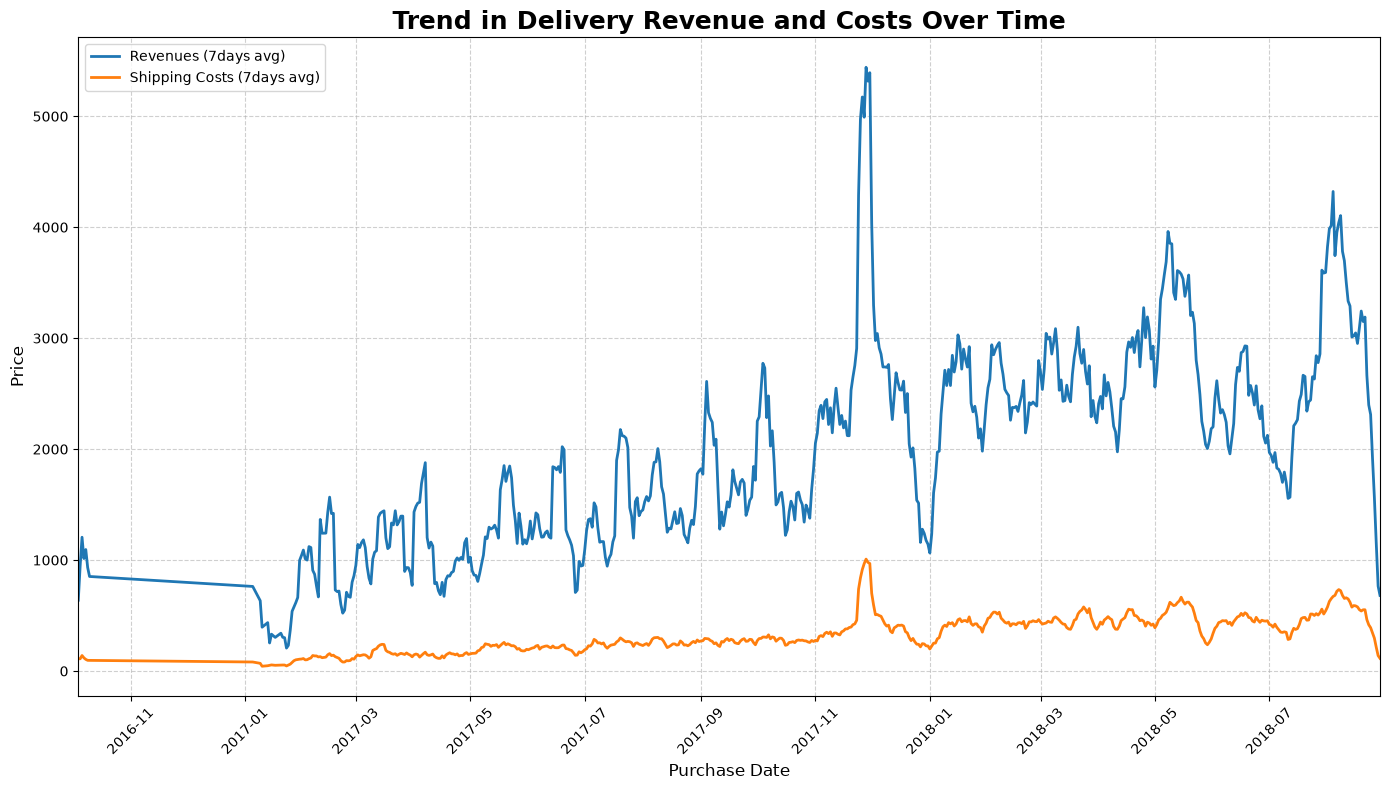

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
df['purchase_date'] = df['order_purchase_timestamp'].dt.date
daily_data = df.groupby('purchase_date')[['price','freight_value']].sum().reset_index()
daily_data['price_7d_avg'] = daily_data['price'].rolling(window=7, min_periods=1).mean()
daily_data['freight_value_7d_avg'] = daily_data['freight_value'].rolling(window=7, min_periods=1).mean()
df_melted = daily_data.melt(
    id_vars='purchase_date',
    value_vars=['price_7d_avg','freight_value_7d_avg'],
    var_name='Metric',
    value_name='Value'
)

df_melted['Metric'] = df_melted['Metric'].replace({
    'price_7d_avg': 'Revenues (7days avg)',
    'freight_value_7d_avg': 'Shipping Costs (7days avg)',
})
#display(df_melted.head(15))
plt.figure(figsize=(14,8))
lplot=sns.lineplot(
    data=df_melted,
    x='purchase_date',
    y='Value',
    hue='Metric',
    linewidth=2,
    legend="brief"
)
first_date = df_melted['purchase_date'].min()
last_date = df_melted['purchase_date'].max()
lplot.set_xlim(first_date, last_date)

plt.title("Trend in Delivery Revenue and Costs Over Time", fontsize=18, fontweight='bold',color='black')
plt.xlabel("Purchase Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True,linestyle='--', alpha=0.6)
plt.legend(loc='upper left',frameon=True)
plt.tight_layout()
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11000\3728721605.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_states, x='customer_state', y='freight_value', palette="Set3")


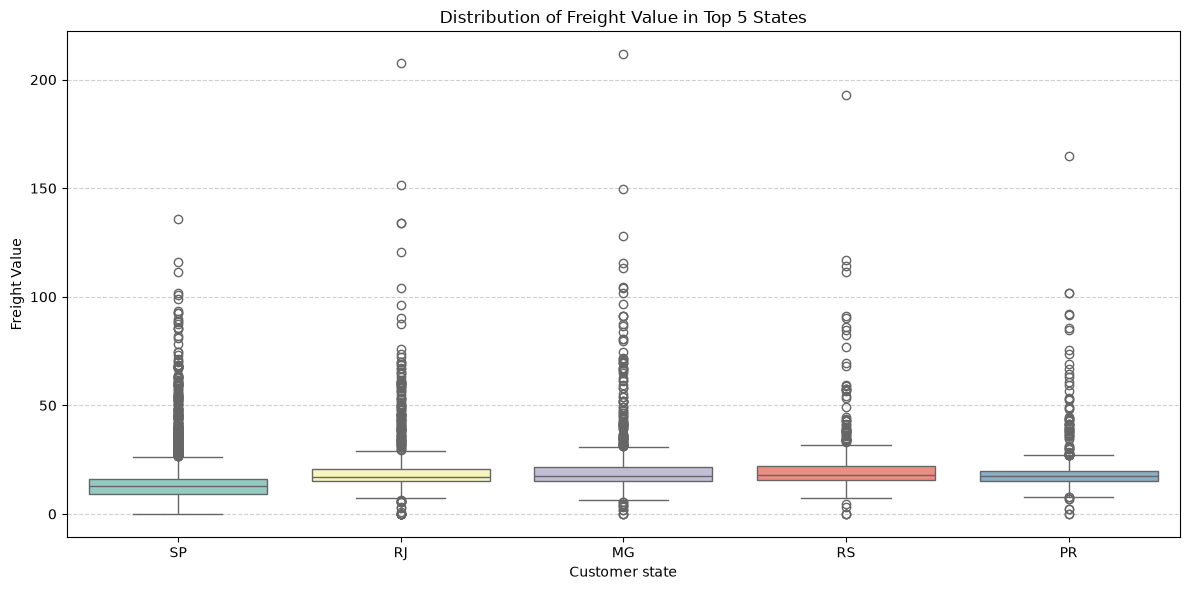

In [21]:
top5_states = df['customer_state'].value_counts().nlargest(5).index
df_top_states = df[df['customer_state'].isin(top5_states)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_states, x='customer_state', y='freight_value', palette="Set3")

plt.title("Distribution of Freight Value in Top 5 States")
plt.xlabel("Customer state")
plt.ylabel("Freight Value")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

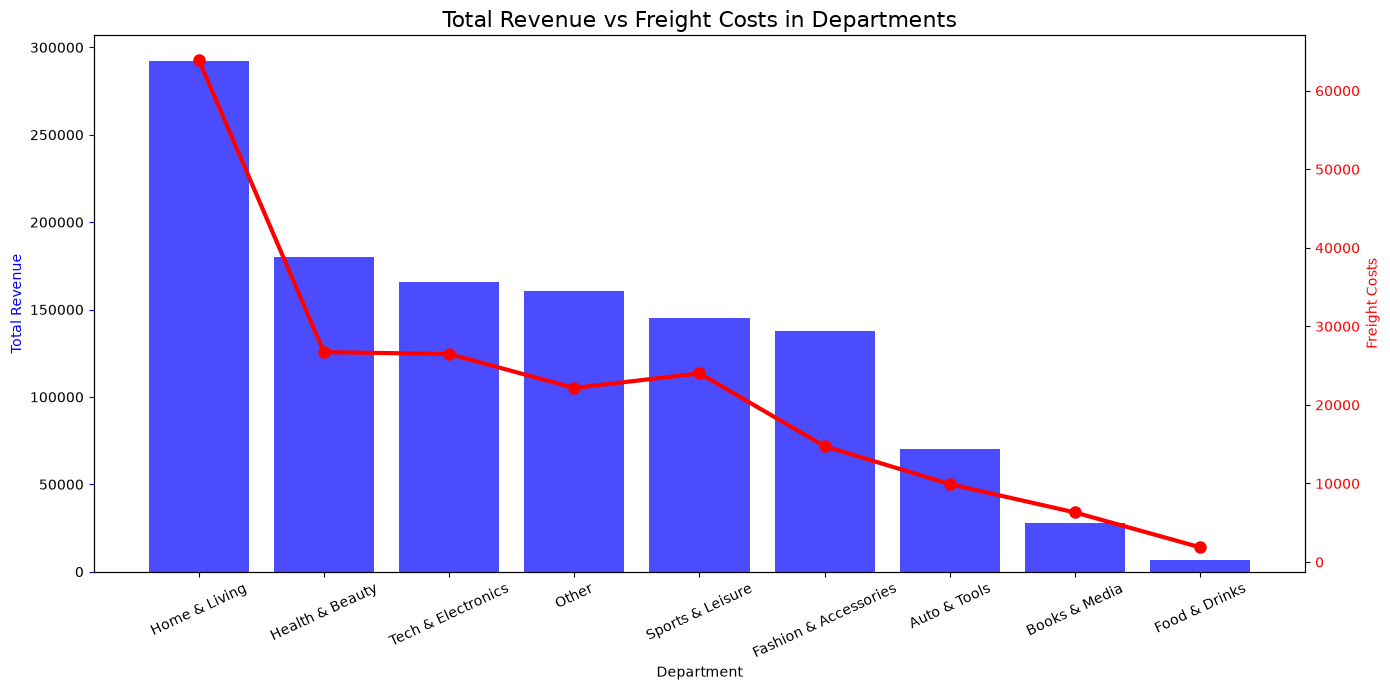

In [22]:
dept_metrics = df.groupby('department')[['price','freight_value']].sum().nlargest(10,'price').reset_index()
fig, fig1 = plt.subplots(figsize=(14,7))
fig1.set_xlabel('Department', fontsize=10)
fig1.set_ylabel('Total Revenue', color='blue' )
fig1.bar(dept_metrics['department'], dept_metrics['price'], color='blue', alpha=0.7, label='Revenue')
fig1.tick_params(axis='y', color='blue')
fig1.tick_params(axis='x', rotation=25)

fig2 = fig1.twinx()
fig2.set_ylabel('Freight Costs', color = 'red')
fig2.plot(dept_metrics['department'], dept_metrics['freight_value'], color='red', marker='o', linewidth=3, markersize=8, label='Freight Costs')
fig2.tick_params(axis='y', labelcolor='red')

plt.title("Total Revenue vs Freight Costs in Departments", fontsize=16)
fig.tight_layout()

plt.show()



Time-Series Trend: The massive revenue spike in November 2017 (Black Friday) proved Olist's infrastructure could handle immense traffic, serving as a tipping point that doubled their daily baseline sales and led to explosive growth during Mother’s and Father’s Day in 2018.

Distribution Boxplot: São Paulo (SP) is the most optimized logistics hub with the lowest and most predictable freight costs, whereas states like Rio de Janeiro (RJ) and Minas Gerais (MG) suffer from extreme positive outliers due to remote delivery challenges.

Dual-Axis Comparison: "Home & Living" is the top revenue-generating department but concurrently incurs the highest absolute freight costs, strongly suggesting that bulky or heavy items significantly impact the platform's logistical expenses.

1. What is "long" (tidy) format and why is it convenient?

The "long" (or tidy) data format involves transforming multiple metric columns into just two columns: one identifying the metric's name and one containing its numerical value. This structure is highly convenient for visualization libraries like Seaborn. By passing the column with metric names to the hue parameter, the library automatically groups the data and generates multiple colored lines. To achieve this in the first trend chart, the pd.melt() method was applied to create a structured dataframe with 'Metric' and 'Value' columns.

2. Which method was used for the comparison chart and why?

For the metric comparison chart (Total Revenue vs. Freight Costs in Departments), the long data format was not utilized. Instead, the .groupby('department')[['price', 'freight_value']].sum() method was used to aggregate the data while keeping the metrics in separate columns (wide format). This specific method was chosen because it enables the use of Matplotlib's twinx() function, allowing both metrics to be plotted on two separate Y-axes. If the data had been melted and plotted on a single axis, the massive difference in numerical scales would have completely flattened the "Freight Costs" line, making the comparison unreadable.

In [23]:
unique_states = df['customer_state'].unique()
geo = pd.read_csv('olist_geolocation_dataset.csv')
state_cords = geo.groupby('geolocation_state')[['geolocation_lat','geolocation_lng']].mean().reset_index()
state_cords.rename(columns={'geolocation_state': 'customer_state'}, inplace=True)
map_data = df.groupby('customer_state', as_index=False)[['price','freight_value']].sum()
map_data = map_data.merge(state_cords, on='customer_state', how='left')

fig_map = px.scatter_geo(
    map_data,
    lat='geolocation_lat',
    lon='geolocation_lng',
    size='price',
    color='freight_value',
    hover_name='customer_state',
    title='Interactive Map: Revenue(size) and Freight Value by State',
    scope='south america',
    color_continuous_scale='Turbo'
)
fig_map.update_traces(marker=dict(line=dict(width=1, color='black')))
fig_map.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig_map.show()

In [24]:
region_manager_map = {
    'SP': 'Sarah (Southeast)', 'RJ': 'Sarah (Southeast)', 'MG': 'Sarah (Southeast)', 'ES': 'Sarah (Southeast)',
    'PR': 'John (South)', 'RS': 'John (South)', 'SC': 'John (South)',
    'BA': 'Michael (Northeast)', 'PE': 'Michael (Northeast)', 'CE': 'Michael (Northeast)',
    'MA': 'Michael (Northeast)', 'PB': 'Michael (Northeast)', 'RN': 'Michael (Northeast)',
    'AL': 'Michael (Northeast)', 'PI': 'Michael (Northeast)', 'SE': 'Michael (Northeast)',
    'AM': 'Anna (North)', 'PA': 'Anna (North)', 'RO': 'Anna (North)', 'TO': 'Anna (North)',
    'AC': 'Anna (North)', 'AP': 'Anna (North)', 'RR': 'Anna (North)',
    'DF': 'Mark (Midwest)', 'GO': 'Mark (Midwest)', 'MT': 'Mark (Midwest)', 'MS': 'Mark (Midwest)'
}
df['regional_manager'] = df['customer_state'].map(region_manager_map)
top8_dept = df['department'].value_counts().nlargest(8).index
df['main_dept'] = df['department'].where(df['department'].isin(top8_dept),'Other')
tree_data =df.groupby(['regional_manager','customer_state','main_dept'], as_index=False).agg({
    'price':'sum',
    'freight_value':'mean'
})

fig_tree = px.treemap(
    tree_data,
    path=['regional_manager','customer_state','main_dept'],
    values='price',
    color='freight_value',
    color_continuous_scale='YlOrRd', 
    range_color=[15, 50], 
    title='Drill-down: Regional Manager ➔ State ➔ Main Department'
)
fig_tree.update_traces(
    textinfo='label+value'
)
fig_tree.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    template='plotly_white',
    paper_bgcolor='white'
)
fig_tree.show()

Based on the hierarchical Treemap, it is clearly visible that the most problematic areas regarding high freight costs (the darkest red color) are located in the regions managed by Michael (Northeast) and Anna (North).

- Specifically, within Michael's region, states such as AL and MA exhibit the highest average transport costs, reaching the upper limit of the color scale.

- Similarly, in Anna's territory (North), all visible states (PA, TO, AM, RO) experience very high shipping costs, highlighted in deep red.

- Interestingly, scatter map reveals that the highest total revenue and the highest absolute sum of freight costs are concentrated in a single location in the Southeast, specifically around the state of São Paulo.

- This indicates that while the Southeast generates massive total logistical costs due to sheer volume, managers in the North and Northeast face lower sales volumes but exceptionally high unit shipping costs, which severely erode profit margins.

If I were managing Michael's region (Northeast), I would implement two strategies:

1) Localized Fulfillment: Initiate partnerships with local suppliers or establish a micro-fulfillment center closer to high-cost states like AL and MA. This would help bypass the extremely expensive cross-country shipping originating from the central and southern hubs.

2) Dynamic Pricing Strategy: Modify the shipping cost policy by introducing dynamic transport fees for the most remote states, or strategically focus marketing efforts exclusively on the highest-margin product categories to offset the severe logistical losses.

Differences Between Methods:

- pd.merge(): Functions identically to an SQL JOIN. It is the most robust method for combining two DataFrames based on a shared common column (or multiple columns). It allows for various join types.

- DataFrame.join(): A specialized method designed to combine DataFrames horizontally by aligning their row indices rather than standard columns. It is most efficient when working with time-series or index-heavy data.

- Series.map(): A highly efficient function applied to a single column (Series) that substitutes each existing value with a new one based on a provided Python dictionary, function, or another Series.

Chosen Approach and Rationale:
To enrich the dataset with the assigned Managers, the Series.map() method was utilized. Task required establishing a simple, static relationship between the Brazilian states and Regional Managers, using a standard Python dictionary was the most optimal solution. Applying .map() directly to the customer_state column was significantly faster and was more memory-efficient than artificially creating an additional DataFrame solely to execute a pd.merge() operation.

In [25]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_metr = df.groupby('order_month').agg(
    total_revenue=('price','sum'),
    total_orders=('order_id','nunique'),
    unique_customers=('customer_unique_id', 'nunique')
).reset_index()

monthly_metr['AOV'] = monthly_metr['total_revenue'] / monthly_metr['total_orders']
monthly_metr['ARPU'] = monthly_metr['total_revenue'] / monthly_metr['unique_customers']

monthly_metr['order_month_str'] = monthly_metr['order_month'].astype(str)
fig_metrics = px.line(
    monthly_metr,
    x='order_month_str',
    y=['AOV','ARPU'],
    title="Monthly Dynamics: Average Order Value vs. Average Revenue Per User",
    labels={'value': 'BRL', 'order_month_str': 'month', 'variable':'metric'}
)
fig_metrics.update_layout(template='plotly_white',hovermode='x unified')
fig_metrics.show()


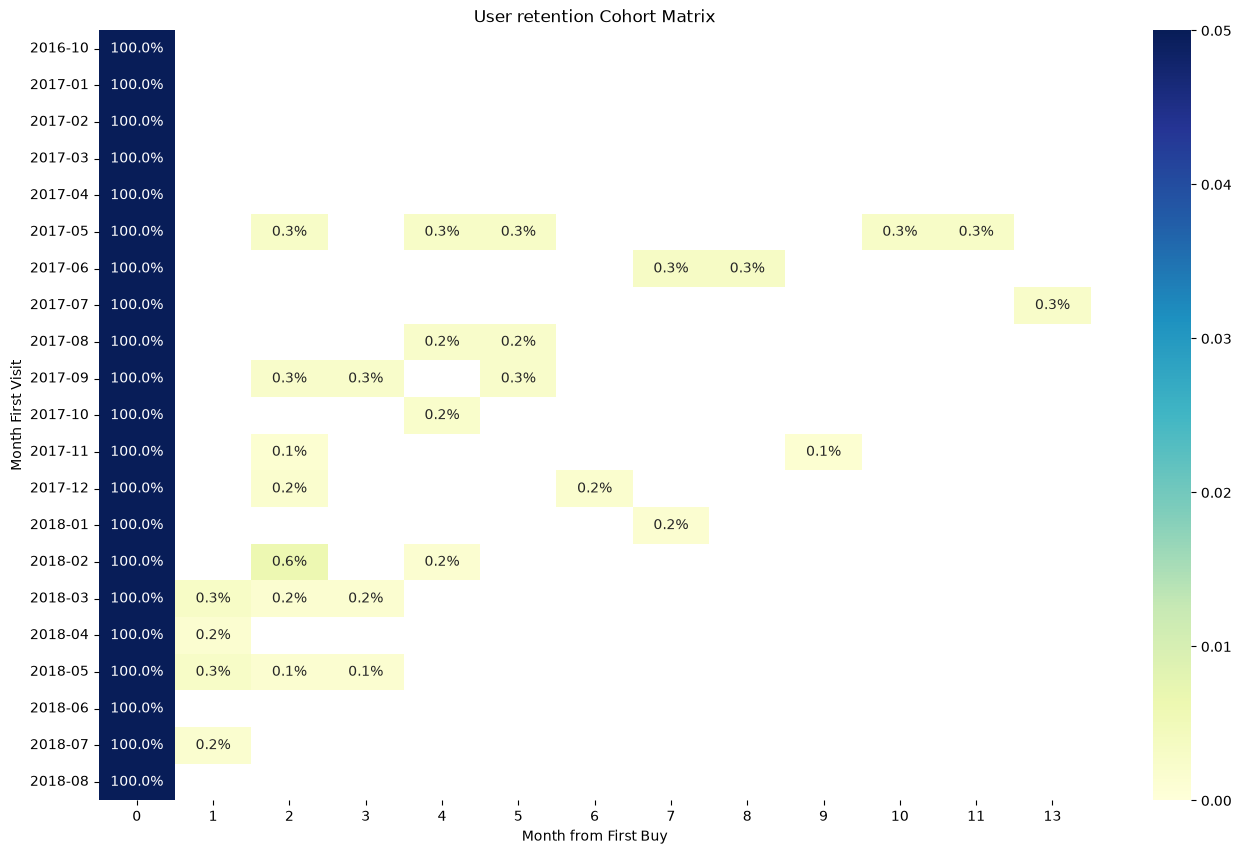

In [26]:

df['cohort_month'] = df.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
df['cohort_index'] = (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 + (df['order_month'].dt.month - df['cohort_month'].dt.month)
cohort_data = df.groupby(['cohort_month','cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month',columns='cohort_index', values='customer_unique_id')
cohort_sizes = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)
plt.figure(figsize=(16,10))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1%',
    cmap='YlGnBu',
    vmin=0.0,
    vmax=0.05
)
plt.title("User retention Cohort Matrix")
plt.ylabel('Month First Visit')
plt.xlabel("Month from First Buy")
plt.show()

In [27]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm = df.groupby('customer_unique_id').agg(
    Recency = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id','nunique'),
    Monetary = ('price', 'sum')
).reset_index()

rfm['m_score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])
rfm['r_score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])

def assign_seg(row):
    r,f,m = row['r_score'], row['f_score'], row['m_score']

    if r==4 and f>=3 and m>=3:
        return 'Champion'
    elif r<=2 and f>=3:
        return 'At risk'
    else:
        return 'Regulars'

rfm['segment'] = rfm.apply(assign_seg, axis=1)
seg_to_show = ['Champion', 'At risk', 'Regulars']
for seg in seg_to_show:
    print(f'\n---Top 5: {seg}---')
    top5 = rfm[rfm['segment'] == seg].sort_values(by='Monetary', ascending=False).head(5)
    display(top5)



---Top 5: Champion---


,customer_unique_id,Recency,Frequency,Monetary,m_score,r_score,f_score,segment
7541,ca27f3dac28fb1063faddd424c9d95fa,32,1,4059.00,4,4,4,Champion
7488,c89e2005ddcd889c687343e2a7d7a115,25,1,1608.99,4,4,4,Champion
7910,d3729a20d98aab032427c9d19d7cb7b9,21,1,1460.99,4,4,4,Champion
9508,fe81bb32c243a86b2f86fbf053fe6140,69,2,1352.30,4,4,4,Champion
9123,f44ffa618df5f8a65899275c93b14ae2,110,1,1260.00,4,4,4,Champion



---Top 5: At risk---


,customer_unique_id,Recency,Frequency,Monetary,m_score,r_score,f_score,segment
8149,da122df9eeddfedc1dc1f5349a1a690c,515,1,4799.00,4,1,4,At risk
8143,d9f8d6be11fb416742c9e35e725303f7,282,1,2899.00,4,2,4,At risk
7052,bd8717655febcdf30f106e9f3cb24628,576,1,2199.99,4,1,3,At risk
6527,af4add6ae61530f1768eef38c9a52c05,441,1,1999.99,4,1,3,At risk
4816,82c0c03a1fb8968a30707374c8566fba,275,1,1999.00,4,2,3,At risk



---Top 5: Regulars---


,customer_unique_id,Recency,Frequency,Monetary,m_score,r_score,f_score,segment
3399,5d09b0d82126457e2a8ebfb9c9a1ffc4,566,1,3699.99,4,1,2,Regulars
363,0a0a92112bd4c708ca5fde585afaa872,334,1,3360.00,4,2,1,Regulars
1533,2ae8173a688e326821403a5b7a6858c2,527,1,2999.89,4,1,1,Regulars
1189,212b7cfb2631b23e85a4645a7cba1733,100,1,2470.50,4,4,1,Regulars
3017,5330670c6666e6f35a2688802fdb235f,408,1,1999.99,4,1,2,Regulars


Customer Drop-off: We lose the vast majority of our user base (>99%) immediately by Month 1 (the very next month after their initial purchase). The cohort matrix demonstrates a brutal drop from 100% in Month 0 to roughly 0.1%–0.3% in Month 1, confirming Olist operates as a purely transactional marketplace rather than a loyalty-driven storefront.

1) Action Plan – Champions: Because they bought recently and spent heavily, the goal is capitalization and advocacy, not discounting. Action: Deploy automated review requests to build platform trust, offer "VIP" priority free shipping on their next order, or trigger cross-sell emails featuring high-margin accessories directly related to their recent large purchase.

2) Action Plan – At Risk: These users have proven they can spend large amounts (High Monetary) but have not returned in over a year (Low Recency). Action: Deploy an aggressive "win-back" campaign featuring a significant, time-sensitive discount code (e.g., 20% off). Because their historical basket size is so large, the high potential ROI justifies the immediate margin hit of a heavy discount.



Categorical Columns:
- np.where() / np.select(): Highly performant but readability plummets when dealing with complex, multi-column conditions.
- pd.qcut() / pd.cut(): Excellent performance and highly readable, specifically designed for binning continuous numerical data into quantiles or fixed intervals.
- .apply(function, axis=1): The slowest method (iterates row-by-row in Python), but offers maximum readability and flexibility for complex, custom business logic.

Our Approach for RFM: We used a hybrid approach. We utilized pd.qcut() to generate the R, F, and M scores because it natively handles the complex math of dividing data into equal percentiles. We then used .apply() with a custom function (assign_seg) for the final segmentation. The business rules required evaluating three distinct variables (R, F, M) simultaneously—in this case, the readability and ease of modifying the business logic far outweighed the minor performance hit.

    groupby().min() aggregates the data, returning a DataFrame with a smaller shape

    transform('min') calculates that same group minimum but broadcasts the value back to the original shape of the DataFrame (returning a Series of the exact same length as the raw data).

Conclusion: .transform('min') is the strictly superior choice for adding a new column directly to the original DataFrame. It aligns perfectly with the existing index, completely bypassing the need to perform a costly and verbose pd.merge() to rejoin aggregated data back to the main table.

In [28]:
df.to_csv('olist_cleaned_dataset_ground_truth.csv', index=False)
rfm.to_csv('olist_rfm_segmentation.csv', index=False)
